What you've already accomplished

Looking back, you've actually completed a lot more than most student projects.

Phase 1 — Discovery

You started with

"Does observable support affect barren plateaus?"

You demonstrated that it does.

Then you asked

"Can we quantify when barren plateaus begin?"

This led to τBP.

Phase 2 — Metric Development

Initially you defined

τ
BP
	​

=1/α

from an exponential fit.

Then you discovered the fit was misleading because of the numerical noise floor.

Instead of ignoring the issue, you diagnosed it by plotting raw variance curves.

That was probably the most important decision in the project.

You replaced it with

first depth where

Var(∂
θ
	​

C)<10
−2

This is a much more defensible operational definition.

Phase 3 — Empirical Modeling

You tested

support only
system only
ratio only
product
support + system

Then

LOOCV
external validation
AIC
AICc
BIC
nested F-test

Instead of assuming your preferred model was correct.

That is excellent scientific practice.

Phase 4 — External Validation

This is where many computational papers stop.

You didn't.

You predicted n=14 before measuring it.

Then measured it.

The prediction generalized well.

That is much stronger evidence than merely fitting existing data.

What remains

Now almost everything left is about convincing a skeptical reviewer.

Notice the council is no longer suggesting

"Try another model."

Instead they are saying

"Prove this model is trustworthy."

That is a huge shift.

Remaining work
Notebook 10

Repeatability

Current status:

🟡 halfway finished

You already showed

CV = 0

Now you need the stronger statistical validation they described:

pointwise CV(L)
safety margin
±2σ band

Those directly address the ambiguity between a genuinely stable threshold crossing and one that is merely stable because of discretization.

In [2]:
# ==========================================
# NOTEBOOK 10
# REPEATABILITY VALIDATION
# ==========================================
!pip install pennylane
import pennylane as qml
from pennylane import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

MAX_DEPTH = 25
N_SAMPLES = 50
THRESHOLD = 1e-2
N_SEEDS = 10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 81.4 MB/s eta 0:00:00


In [3]:
def BrickWall_HEA(n_qubits, params, depth):

    idx = 0

    for d in range(depth):

        for q in range(n_qubits):

            qml.RY(params[idx], wires=q)
            idx += 1

        if d % 2 == 0:

            for q in range(0, n_qubits-1, 2):

                qml.CNOT(wires=[q,q+1])

        else:

            for q in range(1, n_qubits-1, 2):

                qml.CNOT(wires=[q,q+1])

In [4]:
def make_observable(k):

    op = qml.PauliZ(0)

    for q in range(1,k):

        op = op @ qml.PauliZ(q)

    return op

In [5]:
def compute_tau_bp_threshold(
    variances,
    depths,
    threshold=1e-2
):

    for d,v in zip(depths,variances):

        if v < threshold:

            return d

    return MAX_DEPTH+1

In [6]:
# ==========================================
# RAW VARIANCE CURVES
#
# Store every seed separately
# ==========================================

TEST_CASES = [

    (14,2),

    (10,6)

]

variance_by_seed = {}

for n,k in TEST_CASES:

    print("\n"+"="*60)
    print(f"n={n}, k={k}")
    print("="*60)

    dev = qml.device(
        "default.qubit",
        wires=n
    )

    @qml.qnode(dev)
    def cost_fn(params, depth):

        BrickWall_HEA(
            n,
            params,
            depth
        )

        return qml.expval(
            make_observable(k)
        )

    curves = []

    for seed in range(N_SEEDS):

        print(f"Seed {seed+1}/{N_SEEDS}")

        variances = []

        for depth in range(
            1,
            MAX_DEPTH+1
        ):

            grads_all = []

            for _ in range(
                N_SAMPLES
            ):

                params = np.random.uniform(

                    0,

                    2*np.pi,

                    size=depth*n,

                    requires_grad=True

                )

                grads = qml.grad(
                    cost_fn
                )(
                    params,
                    depth
                )

                grads_all.extend(grads)

            variances.append(
                np.var(grads_all)
            )

        curves.append(
            np.array(variances)
        )

    variance_by_seed[(n,k)] = curves


n=14, k=2
Seed 1/10
Seed 2/10
Seed 3/10
Seed 4/10
Seed 5/10
Seed 6/10
Seed 7/10
Seed 8/10
Seed 9/10
Seed 10/10

n=10, k=6
Seed 1/10
Seed 2/10
Seed 3/10
Seed 4/10
Seed 5/10
Seed 6/10
Seed 7/10
Seed 8/10
Seed 9/10
Seed 10/10


In [7]:
def repeatability_analysis(

    variance_curves,

    threshold=1e-2

):

    curves = np.array(
        variance_curves
    )

    mu = np.mean(
        curves,
        axis=0
    )

    sigma = np.std(
        curves,
        axis=0
    )

    cv = np.where(
        mu > 1e-15,
        sigma/mu,
        0
    )

    tau_list = []

    for curve in curves:

        tau = compute_tau_bp_threshold(

            curve,

            range(
                1,
                MAX_DEPTH+1
            ),

            threshold

        )

        tau_list.append(tau)

    tau_mean = np.mean(tau_list)
    tau_std = np.std(tau_list)

    idx = int(round(tau_mean))-1

    if sigma[idx] > 1e-15:

        safety = (

            threshold -

            mu[idx]

        ) / sigma[idx]

    else:

        safety = np.inf

    return {

        "mu":mu,

        "sigma":sigma,

        "cv":cv,

        "tau_mean":tau_mean,

        "tau_std":tau_std,

        "tau_list":tau_list,

        "safety":safety

    }

In [8]:
results = {}

for config in variance_by_seed:

    print("\n")

    print("="*60)

    print(config)

    print("="*60)

    r = repeatability_analysis(

        variance_by_seed[config],

        THRESHOLD

    )

    results[config] = r

    print(

        "tau per seed:",

        r["tau_list"]

    )

    print(

        "tau mean:",

        r["tau_mean"]

    )

    print(

        "tau std:",

        r["tau_std"]

    )

    print(

        "max CV:",

        np.max(r["cv"])*100,

        "%"

    )

    print(

        "Safety margin:",

        r["safety"]

    )



(14, 2)
tau per seed: [13, 13, 13, 13, 13, 13, 15, 13, 13, 13]
tau mean: 13.2
tau std: 0.6
max CV: 9.752217379273295 %
Safety margin: 1.2945101994820205


(10, 6)
tau per seed: [4, 5, 3, 5, 4, 3, 5, 4, 5, 5]
tau mean: 4.3
tau std: 0.7810249675906654
max CV: 14.167345718315035 %
Safety margin: -0.456444628758717


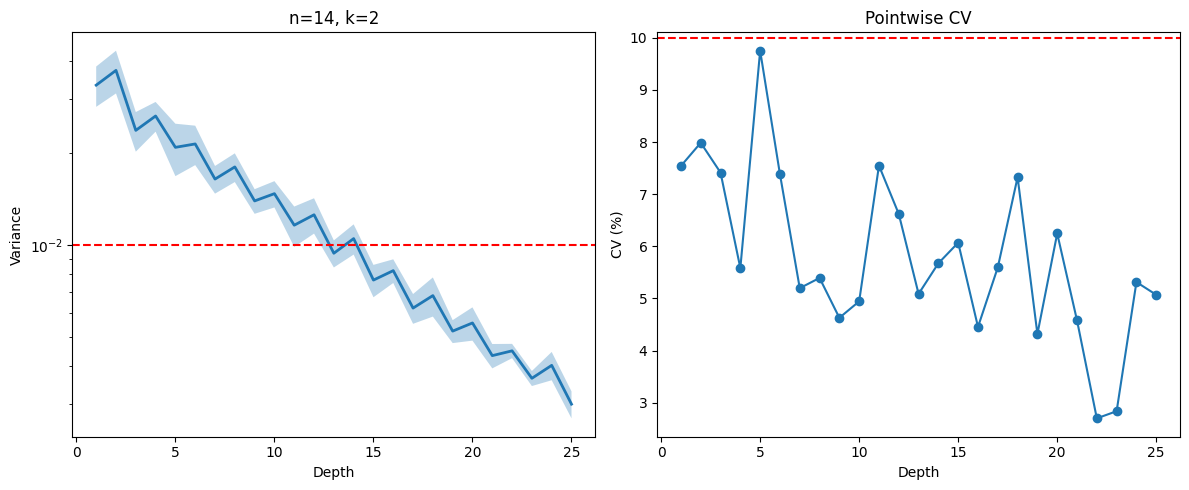

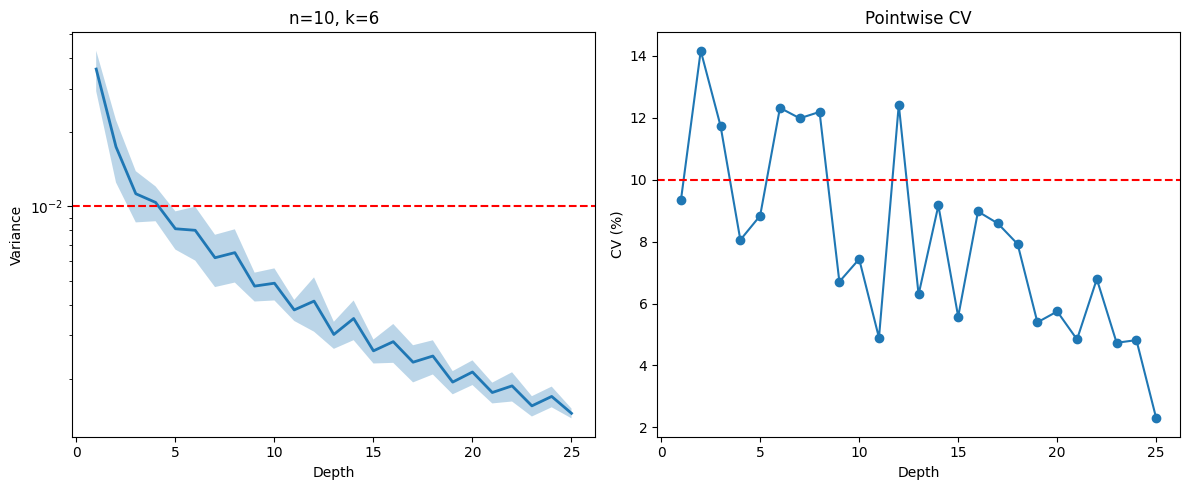

In [9]:
for config,r in results.items():

    n,k = config

    depths = np.arange(
        1,
        MAX_DEPTH+1
    )

    plt.figure(
        figsize=(12,5)
    )

    plt.subplot(1,2,1)

    plt.semilogy(

        depths,

        r["mu"],

        linewidth=2,

        label="Mean"

    )

    plt.fill_between(

        depths,

        np.maximum(
            r["mu"]-2*r["sigma"],
            1e-12
        ),

        r["mu"]+2*r["sigma"],

        alpha=0.3

    )

    plt.axhline(

        THRESHOLD,

        color="red",

        linestyle="--"

    )

    plt.title(
        f"n={n}, k={k}"
    )

    plt.xlabel("Depth")
    plt.ylabel("Variance")

    plt.subplot(1,2,2)

    plt.plot(

        depths,

        100*r["cv"],

        marker="o"

    )

    plt.axhline(

        10,

        color="red",

        linestyle="--"

    )

    plt.xlabel("Depth")
    plt.ylabel("CV (%)")

    plt.title(
        "Pointwise CV"
    )

    plt.tight_layout()

    plt.show()